In [1]:
%pip install -r ../../requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Module M0 — Primer: จากข้อมูลสู่โมเดล

**Day 1, 09:00–10:00 · Offline (CPU)**

เมื่อจบโมดูลนี้ ผู้เรียนจะ:
1. ทบทวนวงจร **data → train → evaluate** ครบรอบเดียว (train/test split, overfitting, metric)
2. เห็นด้วยตาว่า **ข้อมูลไม่มีโครงสร้าง** (ภาพ / ข้อความ / เสียง) ถูกแทนเป็น **ตัวเลข** อย่างไร — pixels, tokens, spectra
3. ยืนยันว่าสภาพแวดล้อมของเครื่องพร้อมสำหรับทั้งหลักสูตร

**Dataset / โมเดลที่ใช้ในโมดูลนี้:** ไม่มี — ข้อมูลทั้งหมด**สังเคราะห์ขึ้นใน notebook** (จึงไม่มี license ของ dataset ต้องอ้างอิง) ไลบรารีที่ใช้: numpy / scikit-learn / matplotlib (BSD-3-Clause) และ PyThaiNLP (Apache-2.0) สำหรับตัดคำไทย

> **ข้อตกลงการรัน:** เปิด JupyterLab จาก repo root (`uv run jupyter lab`) เซลล์แรกของทุก notebook ติดตั้งแพ็กเกจจากไฟล์ pin ที่ให้มา — บนเครื่อง offline จะผ่านทันทีเพราะติดตั้งไว้แล้ว

เซลล์แรกคือ `%pip install -r` จากไฟล์ pin ของ repo — ถ้าคุณติดตั้งผ่าน `uv sync` แล้วจะขึ้นข้อความ `No module named pip` ซึ่ง**ไม่ใช่ปัญหา** (uv venv ไม่มี pip — แพ็กเกจครบแล้วจาก uv.lock) ข้ามผลเซลล์นี้ได้

## 1. ตั้งสภาพแวดล้อม — ตรวจว่าเครื่องพร้อมจริง

สคริปต์ `smoke_test.py` ที่ repo root จะ import ไลบรารีหลักทั้งหมดของหลักสูตร แล้วลองงานจริงเบา ๆ หนึ่งชุด (อ่าน CSV → fit โมเดล → tensor → วาดกราฟ) ถ้าจบด้วย `PASS` แปลว่าเครื่องนี้รันทุกโมดูลของ 3 วันได้

In [2]:
import subprocess  # noqa: E402
import sys  # noqa: E402
from pathlib import Path  # noqa: E402

root = next(
    p
    for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "requirements-offline.txt").exists()
)
r = subprocess.run(
    [sys.executable, str(root / "smoke_test.py")],
    capture_output=True,
    text=True,
)
print("\n".join(r.stdout.splitlines()[-8:]))
assert "PASS" in r.stdout, "smoke test ยังไม่ผ่าน — กลับไปตอนติดตั้งใน README"

  OK   torch tensor math (CPU)
  OK   librosa MFCC
  OK   matplotlib render to file
v1 legacy packages (optional, transitional):
  xgboost==3.4.1 shap==0.52.0 streamlit==1.64.0
  OK   xgboost / shap / streamlit

ผ่าน (PASS) — environment is ready. สภาพแวดล้อมพร้อมใช้งาน


## 2. วงจร data → train → evaluate

งาน ML ทุกโมดูลในหลักสูตรนี้เดินวงจรเดียวกัน:

```text
คำถาม → ข้อมูล → แบ่ง train/test → เทรนบน train → วัดบน test → ตัดสินใจ
```

**ทำไมต้องแบ่งข้อมูล?** ถ้าวัดผลโมเดลด้วยข้อมูลที่มันเคยเห็น (train) เราวัดความจำ ไม่ใช่ความเข้าใจ — เหมือนสอบเทียบเครื่องมือด้วยชิ้นงานชุดเดิมที่ใช้ตอน calibrate แล้วเรียกว่า "ทดสอบ" การวัดที่เชื่อถือได้ต้องใช้ **ชุดทดสอบที่โมเดลไม่เคยเห็น**

เริ่มจากโจทย์ตารางง่าย ๆ: เรามีข้อมูล 90 จุดจากความสัมพันธ์ที่แท้จริงคือเส้น sine + noise (จำลองการวัดที่มี uncertainty)

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


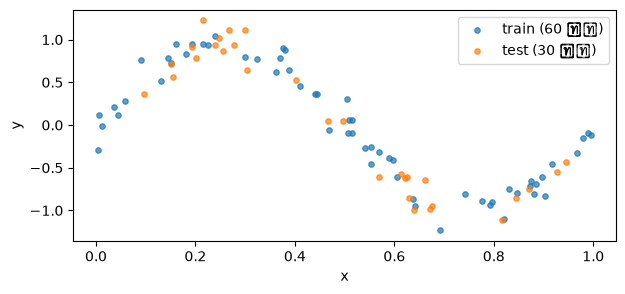

In [3]:
import numpy as np  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
from sklearn.model_selection import train_test_split  # noqa: E402

rng = np.random.default_rng(7)
x = rng.uniform(0.0, 1.0, 90)
y = np.sin(2 * np.pi * x) + rng.normal(0.0, 0.15, 90)
x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, test_size=0.33, random_state=42
)

fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(x_tr, y_tr, s=15, alpha=0.7, label="train (60 จุด)")
ax.scatter(x_te, y_te, s=15, alpha=0.7, label="test (30 จุด)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

## 3. Overfitting — เห็นด้วยตา

เราจะ fit โมเดลพอลิโนเมียล 3 ความยาก (degree 1 / 3 / 15) บนข้อมูลชุดเดียวกัน แล้ววัด MSE (ค่าเฉลี่ยกำลังสองของความคลาดเคลื่อน) ทั้งบน train และ test

- **MSE train ต่ำ แต่ MSE test สูงมาก** = overfit — โมเดลจำ noise แทนที่จะจำรูปแบบ
- **MSE ทั้งคู่สูง** = underfit — โมเดลง่ายเกินไป
- จุดหวาน = ทั้งคู่ต่ำและใกล้กัน

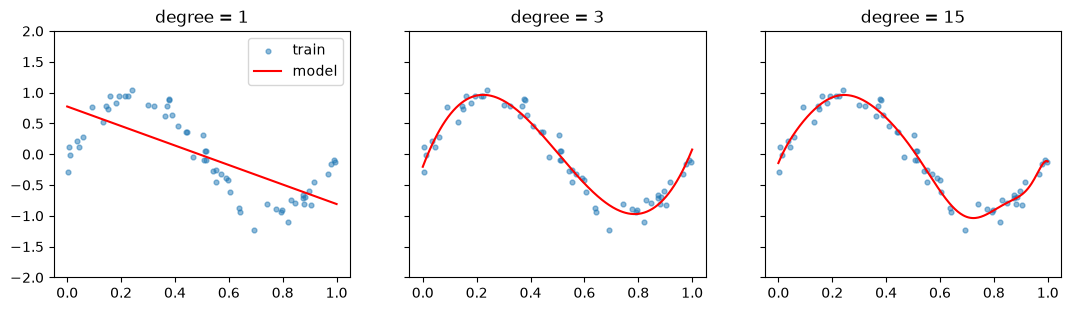

,degree,MSE train,MSE test
0,1,0.2041,0.2368
1,3,0.0205,0.0277
2,15,0.0151,0.0218


In [4]:
import pandas as pd  # noqa: E402
from sklearn.linear_model import LinearRegression  # noqa: E402
from sklearn.metrics import mean_squared_error  # noqa: E402
from sklearn.pipeline import make_pipeline  # noqa: E402
from sklearn.preprocessing import PolynomialFeatures  # noqa: E402

rows = []
xx = np.linspace(0.0, 1.0, 300)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, deg in zip(axes, [1, 3, 15]):
    model = make_pipeline(
        PolynomialFeatures(degree=deg), LinearRegression()
    ).fit(x_tr[:, None], y_tr)
    mse_tr = mean_squared_error(y_tr, model.predict(x_tr[:, None]))
    mse_te = mean_squared_error(y_te, model.predict(x_te[:, None]))
    rows.append({"degree": deg, "MSE train": mse_tr, "MSE test": mse_te})
    ax.scatter(x_tr, y_tr, s=12, alpha=0.5, label="train")
    ax.plot(xx, model.predict(xx[:, None]), "r-", lw=1.5, label="model")
    ax.set_title(f"degree = {deg}")
    ax.set_ylim(-2.0, 2.0)
axes[0].legend()
plt.show()
pd.DataFrame(rows).round(4)

**อ่านตาราง:**

- `degree = 1` — เส้นตรงผ่านกลาง sine: MSE ทั้งคู่สูง (**underfit**)
- `degree = 3` — MSE train และ test ต่ำและใกล้กัน (**ใช้ได้**)
- `degree = 15` — MSE train ต่ำเกือบศูนย์ แต่ MSE test พุ่งสูงกว่าเท่าตัว (**overfit**)

**กฎเหล็กของทุกโมดูลที่เหลือ:** ตัดสินคุณภาพโมเดลจาก **test set เท่านั้น** ไม่ว่า train accuracy จะสวยแค่ไหน

## 4. Metric — วัดกันด้วยอะไร

ปัญหา regression วัดด้วย MSE / MAE (โมดูล regression ของคอร์ส DS) ส่วน **การจำแนก (classification)** ซึ่งเป็นโจทย์หลักของหลักสูตรนี้ วัดด้วย **accuracy** (สัดส่วนทำนายถูก) และ **confusion matrix** (ตารางว่า class ไหนถูกทำนายเป็น class ไหน)

ลองกับโจทย์จำแนก 2 กลุ่ม (จำลอง pass/fail ของชิ้นงานจากค่าที่วัด 2 ช่อง):

accuracy = 0.889


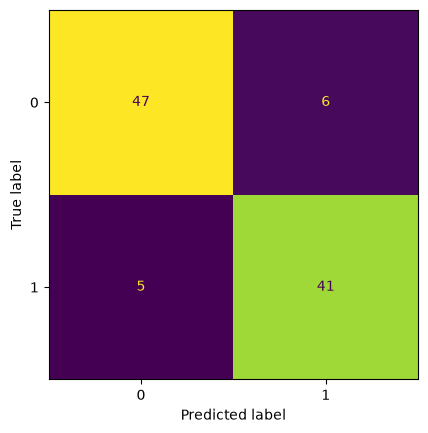

In [5]:
from sklearn.datasets import make_blobs  # noqa: E402
from sklearn.linear_model import LogisticRegression  # noqa: E402
from sklearn.metrics import (  # noqa: E402
    ConfusionMatrixDisplay,
    accuracy_score,
)

X, y = make_blobs(
    n_samples=300,
    centers=[[0.0, 0.0], [2.2, 2.2]],
    cluster_std=1.0,
    random_state=42,
)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X, y, test_size=0.33, random_state=42
)
clf = LogisticRegression().fit(Xb_tr, yb_tr)
pred = clf.predict(Xb_te)
print(f"accuracy = {accuracy_score(yb_te, pred):.3f}")
ConfusionMatrixDisplay.from_predictions(yb_te, pred, colorbar=False)
plt.show()

**อ่าน confusion matrix:** แนวทแยง = ทำนายถูก, ช่องนอกแนวทแยง = ความผิดพลาด ในงานเมโทรโลยี ความผิดพลาดสองแบบมีราคาไม่เท่ากัน — ตรวจชิ้นงาน **ดีแล้วตัดสินว่าเสีย (FP)** เสียค่าทำซ้ำ แต่ **เสียแล้วปล่อยผ่าน (FN)** คือความเสี่ยงต่อคุณภาพ ทำงานจริงเรามองทั้ง accuracy และ *ว่าพลาดทางไหนมากกว่ากัน*

ใน M1 ต่อจากนี้ เราจะเทรนโมเดลจำแนก 10 คลาส และอ่าน confusion matrix 10×10 เพื่อหาว่าคู่คลาสไหนโมเดลแยกไม่ออก

## 5. ข้อมูลไม่มีโครงสร้าง = ตัวเลข

โมเดล ML กินได้แค่ตัวเลข ภาพ ข้อความ และเสียงจึงต้องถูกแปลงเป็น **อาร์เรย์ตัวเลข** ก่อนเข้าโมเดลเสมอ ลองทั้งสาม modality ที่หลักสูตรนี้จะเจอ:

### 5.1 ภาพ → pixels (grid ตัวเลข)

ภาพขาวดำขนาด 8×8 พิกเซล คือตารางเลขจำนวนเต็ม 0–255 ต่อหนึ่งพิกเซล สร้าง "จานตัวอย่าง" สองแบบ — ขอบตั้งและขอบนอน — แล้วพิมพ์ตัวเลขดิบทั้งหมด:

ขอบตั้ง:
[[  0   0   0   0 220 220 220 220]
 [  0   0   0   0 220 220 220 220]
 [  0   0   0   0 220 220 220 220]
 [  0   0   0   0 220 220 220 220]
 [  0   0   0   0 220 220 220 220]
 [  0   0   0   0 220 220 220 220]
 [  0   0   0   0 220 220 220 220]
 [  0   0   0   0 220 220 220 220]]

ขอบนอน:
[[  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [220 220 220 220 220 220 220 220]
 [220 220 220 220 220 220 220 220]
 [220 220 220 220 220 220 220 220]
 [220 220 220 220 220 220 220 220]]


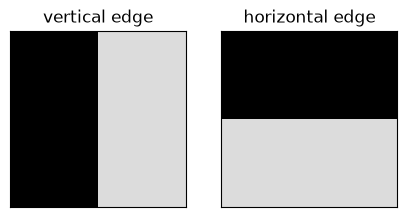

In [6]:
patch_v = np.zeros((8, 8), dtype=np.uint8)
patch_v[:, 4:] = 220  # ครึ่งขวาสว่าง -> ขอบตั้ง
patch_h = np.zeros((8, 8), dtype=np.uint8)
patch_h[4:, :] = 220  # ครึ่งล่างสว่าง -> ขอบนอน

print("ขอบตั้ง:")
print(patch_v)
print()
print("ขอบนอน:")
print(patch_h)

fig, axes = plt.subplots(1, 2, figsize=(5, 2.6))
for ax, p, name in zip(
    axes, [patch_v, patch_h], ["vertical edge", "horizontal edge"]
):
    ax.imshow(p, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

**สังเกต:** สิ่งที่ตาเราเห็นเป็น "ขอบ" คือช่องตารางที่ตัวเลขกระโดดจาก 0 ขึ้น 220 ในทางเดียวกัน ภาพถ่ายเมโทรโลยี (พื้นผิวชิ้นงาน, รอยชำรุด) ก็คือตารางตัวเลขใหญ่ (เช่น 1024×1024) — โจทย์ของ ML คือหารูปแบบในตัวเลขพวกนั้น ใน M1 ภาพจะเป็น 28×28 พิกเซลจาก Fashion-MNIST

### 5.2 ข้อความ → tokens (ลำดับตัวเลข)

ข้อความต้องถูกตัดเป็นหน่วยคำ (token) ก่อน แล้วจึงแทนแต่ละ token ด้วยตัวเลข ภาษาไทยไม่มีช่องว่างคั่นคำ การตัดคำจึงเป็นงานแรกและสำคัญ (โมดูล M3 จะลงลึก):

In [7]:
from pythainlp.tokenize import word_tokenize  # noqa: E402

sent = "ค่าคลาดเคลื่อนของเครื่องมือวัดต้องอยู่ในเกณฑ์ที่กำหนด"
toks = word_tokenize(sent, engine="newmm")
print(f"{len(toks)} tokens: {toks}")

8 tokens: ['ค่า', 'คลาดเคลื่อน', 'ของ', 'เครื่องมือวัด', 'ต้อง', 'อยู่ในเกณฑ์', 'ที่', 'กำหนด']

**สังเกต:** คำเดียวอาจถูกตัดเป็นหลาย token ("เครื่องมือวัด" → "เครื่องมือ" + "วัด") ตัวเลขจริงที่เข้าโมเดลคือ ID ของแต่ละ token หรือเวกเตอร์ embedding — M3 จะเห็นของจริง

### 5.3 เสียง → spectrum / spectrogram

เสียงดิบคือตัวเลขกดดันอากาศต่อเวลา แปลงด้วย Fourier transform ได้ "สเปกตรัม" — พลังงานแต่ละความถี่ สังเคราะห์สัญญาณผสม 2 ความถี่ + noise แล้วหาสเปกตรัม:

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3597 (\N{THAI CHARACTER YO YING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3603 (\N{THAI CHARACTER NO NEN}) missing from font(s) DejaV

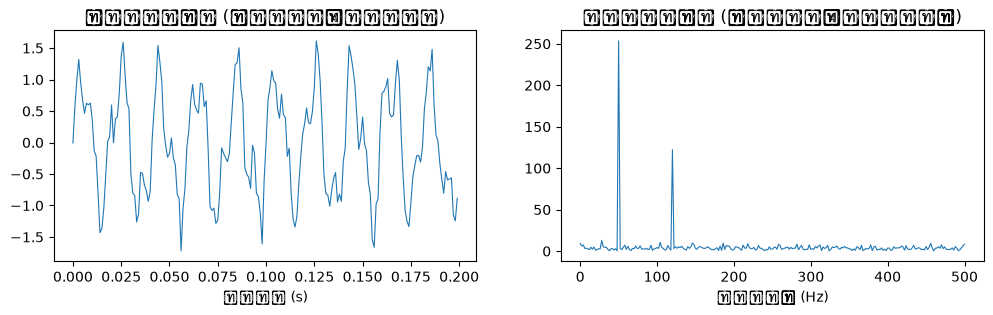

In [8]:
fs = 1000  # อัตราตัวอย่าง 1000 ครั้ง/วินาที
t = np.arange(0.0, 0.5, 1 / fs)
sig = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)
sig += rng.normal(0.0, 0.2, len(t))

spec = np.abs(np.fft.rfft(sig))
freqs = np.fft.rfftfreq(len(t), 1.0 / fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(t[:200], sig[:200], lw=0.8)
axes[0].set_xlabel("เวลา (s)")
axes[0].set_title("สัญญาณดิบ (ตัวเลขต่อเวลา)")
axes[1].plot(freqs, spec, lw=0.8)
axes[1].set_xlabel("ความถี่ (Hz)")
axes[1].set_title("สเปกตรัม (ตัวเลขต่อความถี่)")
plt.show()

**อ่านกราฟ:** สัญญาณดิบดูเป็น "ไขว้เขว" เพราะ noise แต่สเปกตรัมเผย peak ชัดที่ **50 Hz** และ **120 Hz** — ตำแหน่งที่เราใส่ไว้ตอนสังเคราะห์ นี่คือพลังของการแทนข้อมูลให้ถูกมิติ ใน M4 เสียงจริงจะถูกแทนด้วย **mel-spectrogram** (สเปกตรัมต่อเวลา) ซึ่งเป็น "ภาพ" อีกแบบที่ CNN กินได้

---

## 6. สรุป — แผนที่ของหลักสูตร

| Modality | ตัวเลขที่ใช้แทน | โมดูล |
|---|---|---|
| ภาพ | pixel grid 28×28 (M1), ภาพจริง (M6) | M1, M6, Capstone A |
| ข้อความ | token ID / embedding | M3, Capstone C |
| เสียง | waveform → MFCC / spectrogram | M4, M5 |

วงจรเดียวกันทุกครั้ง: **ข้อมูล → แทนเป็นตัวเลข → เทรน → วัดผลบน test set**

โมดูลถัดไป (M1) เราจะเทรนโมเดลจำแนกภาพด้วยมือเราเอง 3 วิธีบนข้อมูลชุดเดียวกัน และเรียนรู้ว่า "ข้อมูลน้อย" เปลี่ยนคำตอบอย่างไร — โจทย์จริงของงานเมโทรโลยี